In [1]:
from sklearn.model_selection import train_test_split
import numpy as np
from models import EEGNet
from tensorflow.keras.callbacks import ModelCheckpoint
from pyriemann.estimation import XdawnCovariances
from pyriemann.tangentspace import TangentSpace
#from pyriemann.utils.viz import plot_confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot as plt
import util
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from numpy import multiply
from tensorflow.keras import utils as np_utils
from pyriemann.utils.viz import plot_confusion_matrix






['/Users/bobbeashel/Desktop/CITS4010/Project', '/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python38.zip', '/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8', '/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/lib-dynload', '', '/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/site-packages', '/Users/bobbeashel/Desktop/CITS4010/ARL-EEGMODELS/arl-eegmodels-master']
1.24.3


In [2]:
#from braindecode.preprocessing import Preprocessor, exponential_moving_standardize, preprocess, create_windows_from_events
    
'''
from braindecode.datasets import MOABBDataset

for i in [1,2,3,4,5,6,7,8,9]:
    subject_id = i
    dataset = MOABBDataset(dataset_name="BNCI2014_001", subject_ids=[subject_id])
    
    low_cut_hz = 4.  # low cut frequency for filtering
    high_cut_hz = 38.  # high cut frequency for filtering
    # Parameters for exponential moving standardization
    factor_new = 1e-3
    init_block_size = 1000
    # Factor to convert from V to uV
    factor = 1e6

    preprocessors = [
        Preprocessor('pick_types', eeg=True, meg=False, stim=False),
        # Keep EEG sensors
        Preprocessor(lambda data: multiply(data, factor)),  # Convert from V to uV
        Preprocessor('filter', l_freq=low_cut_hz, h_freq=high_cut_hz),
        # Bandpass filter
        Preprocessor(exponential_moving_standardize,
                    # Exponential moving standardization
                    factor_new=factor_new, init_block_size=init_block_size)
    ]

    # Transform the data
    preprocess(dataset, preprocessors, n_jobs=-1)

    trial_start_offset_seconds = -0.5
    # Extract sampling frequency, check that they are same in all datasets
    sfreq = dataset.datasets[0].raw.info['sfreq']
    assert all([ds.raw.info['sfreq'] == sfreq for ds in dataset.datasets])

    # Calculate the trial start offset in samples.
    trial_start_offset_samples = int(trial_start_offset_seconds * sfreq)

    # Create windows using braindecode function for this. It needs parameters to define how
    # trials should be used

    n_preds_per_input = 1 #? 
    input_window_samples = 1000

    windows_dataset = create_windows_from_events(
    dataset,
    trial_start_offset_samples=trial_start_offset_samples,
    trial_stop_offset_samples=0,
    window_size_samples=input_window_samples,
    window_stride_samples=n_preds_per_input,
    drop_last_window=False,
    preload=True
    )

    print(type(windows_dataset))
    print(windows_dataset.shape)
'''


'\nfrom braindecode.datasets import MOABBDataset\n\nfor i in [1,2,3,4,5,6,7,8,9]:\n    subject_id = i\n    dataset = MOABBDataset(dataset_name="BNCI2014_001", subject_ids=[subject_id])\n    \n    low_cut_hz = 4.  # low cut frequency for filtering\n    high_cut_hz = 38.  # high cut frequency for filtering\n    # Parameters for exponential moving standardization\n    factor_new = 1e-3\n    init_block_size = 1000\n    # Factor to convert from V to uV\n    factor = 1e6\n\n    preprocessors = [\n        Preprocessor(\'pick_types\', eeg=True, meg=False, stim=False),\n        # Keep EEG sensors\n        Preprocessor(lambda data: multiply(data, factor)),  # Convert from V to uV\n        Preprocessor(\'filter\', l_freq=low_cut_hz, h_freq=high_cut_hz),\n        # Bandpass filter\n        Preprocessor(exponential_moving_standardize,\n                    # Exponential moving standardization\n                    factor_new=factor_new, init_block_size=init_block_size)\n    ]\n\n    # Transform the d

In [3]:
X_train, Y_train, X_test, Y_test, chans, kernels, samples, names = util.get_bci_2a()

Extracting EDF parameters from /Users/bobbeashel/Desktop/CITS4010/Project/data/BCICIV_2a_gdf/A01T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/contextlib.py:120: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['769', '770', '771', '772']
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 501 original time points ...
0 bad epochs dropped
(288, 22, 500)
(288, 22, 500)
LABELS:  [3 2 1 0 0 1 2 3 1 2 0 0 0 3 1 1 0 0 2 0 1 3 3 2 0 3 3 1 3 3 1 0 1 2 2 2 3
 2 0 3 1 2 1 2 3 1 2 0 0 0 3 1 0 2 0 2 1 3 0 2 2 0 2 1 3 3 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
/Users/bobbeashel/Desktop/CITS4010/Project/util.py:127: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  all_segments.append(epochs.get_data()[:,:chans,:-1]) # i did this -1 because the samples was always exactly 1 too high.
/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/contextlib.py:120: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['783']
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 501 original time points ...
0 bad epochs dropped
(288, 22, 500)
(288, 22, 500)
LABELS:  [0 1 1 0 1 0 1 2 1 3 0 2 1 0 3 3 3 3 3 0 2 1 0 0 2 3 0 2 2 2 0 1 0 1 1 0 1
 2 1 2 2 3 2 2 3 3 3 3 3 2 1 0 0 1 2 3 1 2 0 0 0 3 1 1 0 0 2 0 1 3 3 2 0 3
 3 1 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
/Users/bobbeashel/Desktop/CITS4010/Project/util.py:127: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  all_segments.append(epochs.get_data()[:,:chans,:-1]) # i did this -1 because the samples was always exactly 1 too high.


In [4]:
# take 50/25/25 percent of the data to train/validate/test
X_train, X_temp, Y_train, Y_temp = train_test_split(X_test, Y_test, test_size=0.5, stratify=Y_train)
X_validate, X_test, Y_validate, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, stratify=Y_temp)

X_train      = X_train.reshape(X_train.shape[0], chans, samples, kernels)
X_validate   = X_validate.reshape(X_validate.shape[0], chans, samples, kernels)
X_test       = X_test.reshape(X_test.shape[0], chans, samples, kernels)

Y_train = np_utils.to_categorical(Y_train) # One hot encoding format for probabilistic classification
Y_validate = np_utils.to_categorical(Y_validate) # One hot encoding format for probabilistic classification
Y_test = np_utils.to_categorical(Y_test) # One hot encoding format for probabilistic classification

# 2) Standardize per-channel (over time & trials)
mean  = X_train.mean(axis = (0,2), keepdims=True)
std   = X_train.std(axis = (0,2), keepdims=True)
X_train    = (X_train   - mean) / std
X_validate = (X_validate- mean) / std
X_test     = (X_test    - mean) / std

print('X_train shape:', X_train.shape)
print('y train shape', Y_train.shape)
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

# configure the EEGNet-8,2,16 model with kernel length of 32 samples (other 
# model configurations may do better, but this is a good starting point)
model = EEGNet(nb_classes = 4, Chans = chans, Samples = samples, 
               dropoutRate = 0.5, kernLength = 32, F1 = 8, D = 2, F2 = 16, 
               dropoutType = 'Dropout')

# compile the model and set the optimizers
model.compile(loss='categorical_crossentropy', optimizer='adam', 
              metrics = ['accuracy'])

numParams    = model.count_params()    

# set a valid path for your system to record model checkpoints
checkpointer = ModelCheckpoint(filepath='/tmp/checkpoint.h5', verbose=1, save_best_only=True)

###############################################################################
# if the classification task was imbalanced (significantly more trials in one
# class versus the others) you can assign a weight to each class during 
# optimization to balance it out. This data is approximately balanced so we 
# don't need to do this, but is shown here for illustration/completeness. 
###############################################################################

class_weights = {0:1, 1:1, 2:1, 3:1}

X_train shape: (144, 22, 500, 1)
y train shape (144, 4)
144 train samples
72 test samples


In [5]:
################################################################################
# fit the model. Due to very small sample sizes this can get
# pretty noisy run-to-run, but most runs should be comparable to xDAWN + 
# Riemannian geometry classification (below)
################################################################################
fittedModel = model.fit(X_train, Y_train, batch_size = 16, epochs = 300, 
                        verbose = 2, validation_data=(X_validate, Y_validate),
                        callbacks=[checkpointer])

Epoch 1/300

Epoch 1: val_loss improved from inf to 1.38567, saving model to /tmp/checkpoint.h5
9/9 - 0s - loss: 1.4193 - accuracy: 0.2708 - val_loss: 1.3857 - val_accuracy: 0.2778 - 499ms/epoch - 55ms/step
Epoch 2/300

Epoch 2: val_loss improved from 1.38567 to 1.38552, saving model to /tmp/checkpoint.h5
9/9 - 0s - loss: 1.3635 - accuracy: 0.3403 - val_loss: 1.3855 - val_accuracy: 0.3333 - 187ms/epoch - 21ms/step
Epoch 3/300


/Users/bobbeashel/.pyenv/versions/3.8.20/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 3: val_loss improved from 1.38552 to 1.38531, saving model to /tmp/checkpoint.h5
9/9 - 0s - loss: 1.3520 - accuracy: 0.3542 - val_loss: 1.3853 - val_accuracy: 0.2639 - 183ms/epoch - 20ms/step
Epoch 4/300

Epoch 4: val_loss improved from 1.38531 to 1.38486, saving model to /tmp/checkpoint.h5
9/9 - 0s - loss: 1.3412 - accuracy: 0.3819 - val_loss: 1.3849 - val_accuracy: 0.3056 - 186ms/epoch - 21ms/step
Epoch 5/300

Epoch 5: val_loss improved from 1.38486 to 1.38416, saving model to /tmp/checkpoint.h5
9/9 - 0s - loss: 1.3497 - accuracy: 0.3889 - val_loss: 1.3842 - val_accuracy: 0.2917 - 182ms/epoch - 20ms/step
Epoch 6/300

Epoch 6: val_loss improved from 1.38416 to 1.38338, saving model to /tmp/checkpoint.h5
9/9 - 0s - loss: 1.3271 - accuracy: 0.3681 - val_loss: 1.3834 - val_accuracy: 0.2917 - 185ms/epoch - 21ms/step
Epoch 7/300

Epoch 7: val_loss improved from 1.38338 to 1.38247, saving model to /tmp/checkpoint.h5
9/9 - 0s - loss: 1.3151 - accuracy: 0.4514 - val_loss: 1.3825 - val_

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 22, 500, 1)]      0         
                                                                 
 conv2d (Conv2D)             (None, 22, 500, 8)        256       
                                                                 
 batch_normalization (Batch  (None, 22, 500, 8)        32        
 Normalization)                                                  
                                                                 
 depthwise_conv2d (Depthwis  (None, 1, 500, 16)        352       
 eConv2D)                                                        
                                                                 
 batch_normalization_1 (Bat  (None, 1, 500, 16)        64        
 chNormalization)                                                
                                                             

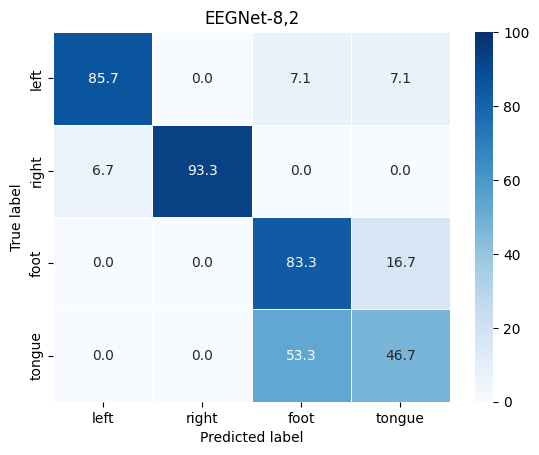

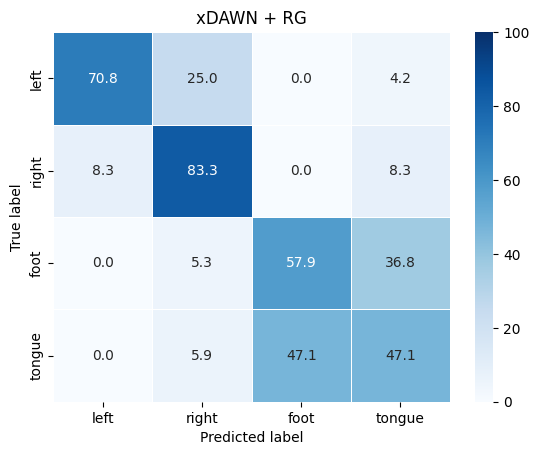

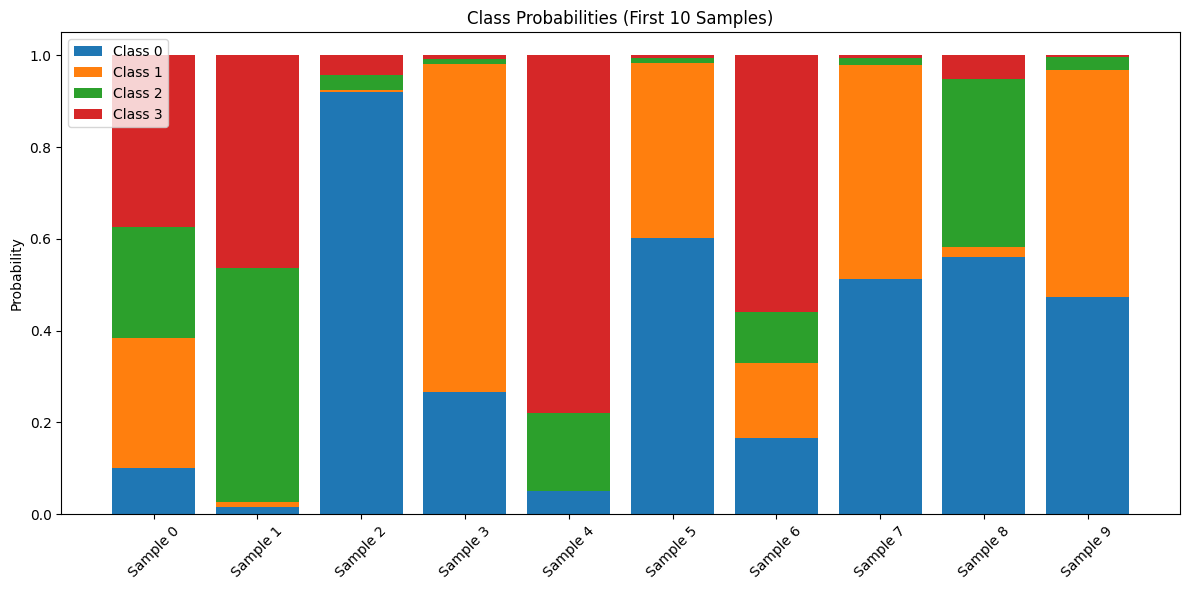

In [11]:


#########################################################################################################

# load optimal weights
model.load_weights('/tmp/checkpoint.h5')

#predict
print(model.summary())
probs = model.predict(X_test)

k=1.5 # If k is 1, just accept all highest probs (preds       = probs.argmax(axis = -1)  )
preds, Y_test_eegnet = util.accept_confident_probabilities(probs, k, Y_test)
acc         = np.mean(preds == Y_test_eegnet.argmax(axis=-1))
print("Classification accuracy EEGNet: %f " % (acc))
print((len(Y_test) - len(Y_test_eegnet)), " samples deleted")

############################# xDAWN + RG Portion ##############################

# code is taken from PyRiemann's ERP sample script, which is decoding in 
# the tangent space with a logistic regression

n_components = 2  # pick some components

# set up sklearn pipeline
clf = make_pipeline(XdawnCovariances(n_components),
                    TangentSpace(metric='riemann'),
                    LogisticRegression())

preds_rg     = np.zeros(len(Y_test))

# reshape back to (trials, channels, samples)
X_train_reshaped      = X_train.reshape(X_train.shape[0], chans, samples)
X_test_reshaped       = X_test.reshape(X_test.shape[0], chans, samples)

# train a classifier with xDAWN spatial filtering + Riemannian Geometry (RG)
# labels need to be back in single-column format
clf.fit(X_train_reshaped, Y_train.argmax(axis = -1))
preds_rg     = clf.predict(X_test_reshaped)

# Printing the results
acc2         = np.mean(preds_rg == Y_test.argmax(axis = -1))
print("Classification accuracy xDAWN + RG: %f " % (acc2))

# plot the confusion matrices for both classifiers

plt.figure(0)
plot_confusion_matrix(preds, Y_test_eegnet.argmax(axis = -1), names, title = 'EEGNet-8,2')


plt.figure(1)
plot_confusion_matrix(preds_rg, Y_test.argmax(axis = -1), names, title = 'xDAWN + RG')

plt.show()

# Show only the first 10 samples for clarity
samples_to_plot = 10
util.plot_predicted_probs(probs, samples_to_plot)
